# Julia for Simulation Analysis

Practical Julia habits for post-processing work: reproducible environments, what compile-time
latency is (and is not), memory discipline on laptop-scale machines, and measured
multithreading. Nothing here is Mera-specific dogma, these are the standard patterns of the
language, applied to snapshot analysis.

## 1. Environments: make every project reproducible

Julia's package manager pins exact versions per project. In a fresh directory:

```julia
julia> ]                       # enter package mode
(@v1.12) pkg> activate .       # this directory becomes the project
(myproject) pkg> add Mera CairoMakie
```

That writes `Project.toml`/`Manifest.toml`; anyone (including future you) reproduces the exact
stack with `] instantiate`. Start Julia with `julia --project=.` to use it.

## 2. Compile-time latency: pay once per session

Julia compiles functions the first time they run with a given argument type. Mera
precompiles its analysis paths at install time, so the ones you reach first are already
compiled: in a fresh session a first `projection` takes about 0.05 s and a first `getvar`
about 0.04 s, the same as every later call. What still carries a one-off cost is the
readers, roughly 4 s on the first `gethydro` and nothing after it. The pattern below is
worth knowing anyway, because it applies to any function you write yourself:


In [1]:
# Example-data root. Point this at your own simulation folder, or set the
# MERA_EXAMPLES environment variable; every path below is built from it.
MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests");

using Mera, CairoMakie
CairoMakie.activate!()
BASE = MERA_EXAMPLES   # <-- change me
info = getinfo(100, joinpath(BASE, "RAMSES/spiral_clumps"), verbose=false)
gas  = gethydro(info, verbose=false, show_progress=false)
proj() = projection(gas, :sd; pxsize=[0.4, :kpc], verbose=false, show_progress=false)
t1 = @elapsed proj()      # includes compilation
t2 = @elapsed proj()      # pure runtime
println("first call: ", round(t1, digits=2), " s   second call: ", round(t2, digits=3), " s")

[ Info: Precompiling Mera [02f895e8-fdb1-4346-8fe6-c721699f5126](cache misses: include_dependency fsize change (4), wrong source (1), dep missing source (1), mismatched flags (2))


[ Info: Precompiling Mera [02f895e8-fdb1-4346-8fe6-c721699f5126] (cache misses: include_dependency fsize change (8), wrong source (2), dep missing source (2), mismatched flags (4))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up



*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0 | Julia 1.12.7 | 8 threads



...

[ Info: Precompiling MeraMakieExt [defab1b5-6ec5-5409-a2f4-69ec619b2a0e] (cache misses: wrong dep version loaded (2))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[ Info: Mera v1.8.0


first call: 13.67

 s   second call: 0.061 s


Keep one session alive while you work (REPL, Jupyter, VS Code) instead of re-launching
`julia script.jl` per plot, relaunching pays the compile tax every time.

## 3. Your own loops are fast, write them

Custom per-cell analysis needs no vectorisation gymnastics. A plain loop over columns compiles
to native code; the one rule is to keep it in a **function** (globals are slow):


In [2]:
rho = getvar(gas, :rho, :g_cm3); T = getvar(gas, :T, :K); vol = getvar(gas, :volume, :cm3)
# mass-weighted mean temperature of dense gas, as an explicit loop
function mwT(rho, T, vol; thresh=1e-24)
    num = 0.0; den = 0.0
    @inbounds for i in eachindex(rho)
        rho[i] > thresh || continue
        m = rho[i] * vol[i]
        num += m * T[i]; den += m
    end
    return num / den
end
mwT(rho, T, vol)                                   # compile
t = @elapsed mwT(rho, T, vol)
println("mass-weighted T (ρ>1e-24 g/cm³): ", round(mwT(rho, T, vol), sigdigits=4),
        " K   —   ", length(rho), " cells in ", round(1e3 * t, digits=2), " ms")

mass-weighted T (ρ>1e-24 g/cm³): 67870.0

 K   —   590311 cells in 0.2 ms


## 4. Memory discipline on laptop-scale machines

The levers, in the order to reach for them:

1. **Load less**: `gethydro(info; lmax=…)` caps the refinement level;
   `xrange/yrange/zrange` load a spatial window (applied while reading, the full box never
   materialises).
2. **Select variables**: `gethydro(info, [:rho, :p])` reads only what you need.
3. **One snapshot at a time**: in loops over outputs, let each object go out of scope before
   loading the next (the `timeseries` helper does this for you, with `GC.gc()` between
   snapshots).
4. **Watch it**: `usedmemory(gas)` for objects, `storageoverview(info)` before loading.

### Why the Julia version matters more here than for most packages

Reading a RAMSES snapshot is **allocation bound**. Measured across eight refinement levels
of a production run, read time tracks bytes allocated almost exactly, at a steady
1.30 GB/s with an R^2 of 0.9985 over a tenfold range of data. A full-resolution read
allocated 665 GB to deliver a 53 GB snapshot, and spent 62 s in garbage collection.

Two consequences:

- Work in Julia's **allocator and garbage collector** lands directly on Mera's dominant
  cost, more than it would for a package whose time goes on arithmetic. That is the
  reason to run a recent Julia rather than the oldest supported one, and Mera keeps 1.10
  as its floor only so it keeps working, not because it is the version to choose.
- **Know what the GC threads are.** Julia collects in parallel, and the mark phase gets
  as many threads as you have compute threads by default, so you already have them:

  ```
  julia -t 16                    # 16 compute, and 16 GC by default
  julia -t 16 --gcthreads=8      # 16 compute, 8 for the GC mark phase
  ```

  `-t N,M` does **not** set GC threads; the second number is the interactive pool. Use
  `--gcthreads` or `JULIA_NUM_GC_THREADS`, and check with `Threads.ngcthreads()`. The
  reference benchmarks ran 24 compute and 24 GC, which is simply the default.

Mera's own numbers come from Julia 1.12, and the package is tested on 1.10, 1.11, 1.12 and 1.13
on every push. What is not published is a like-for-like comparison **between** those
versions on the same data: nobody has run one, so treat "newer is better here" as
following from the mechanism above rather than from a measurement. If you want the real
answer for your workload, `benchmark_report` gives it in one call per version.


In [3]:
small = gethydro(info; lmax=6, xrange=[-8., 8.], yrange=[-8., 8.], zrange=[-2., 2.],
                 center=[:bc], range_unit=:kpc, vars=[:rho], verbose=false, show_progress=false)
println(length(small.data), " cells (windowed, lmax=6, :rho only)  vs  ",
        length(gas.data), " full (lmax=", gas.lmax, ")")
usedmemory(small)

576 cells (windowed, lmax=6, :rho only)  vs  

590311 full (lmax=7)
Memory used: 

481.456 KB


(481.4560546875, "KB")

## 5. Multithreading, measured

Start Julia with threads (`julia -t 8` or `JULIA_NUM_THREADS=8`) and Mera's heavy paths
(reading, projections) use them automatically; every such function takes `max_threads=` to
throttle a single call. Three rules of thumb:

- results are **independent of the thread count** (per-thread buffers, summed at the end);
- **threading pays where there is something to divide**, and different paths divide different
  things. An axis-aligned `projection` splits the work **by variable**: internally it takes
  `min(max_threads, nthreads(), number_of_variables)` threads, so asking for one quantity uses
  exactly one thread however many you offer it, while several quantities in one call run in
  parallel. The rotated and off-axis deposit kernels split **by cell** instead, so a single
  quantity already uses every thread. That is why the off-axis `:exact` example below scales on
  one variable where an axis-aligned projection of the same quantity would stay flat;
- BLAS keeps its own thread pool, keep `Julia threads × BLAS threads` within your core budget.

Measured on whatever this session was started with, and the sweep stops there: asking for
more than `Threads.nthreads()` is clamped internally, so the extra points would just repeat
the last one. **Illustrative, not a benchmark**, your times will differ:


Julia threads: 8

  ->  testing [1, 2, 4, 8]


max_threads=1  105.12

 s   speedup ×1.0
max_threads=2  76.07 s   speedup ×1.38
max_threads=4  52.85 s   speedup ×1.99
max_threads=8  29.5 s   speedup ×3.56


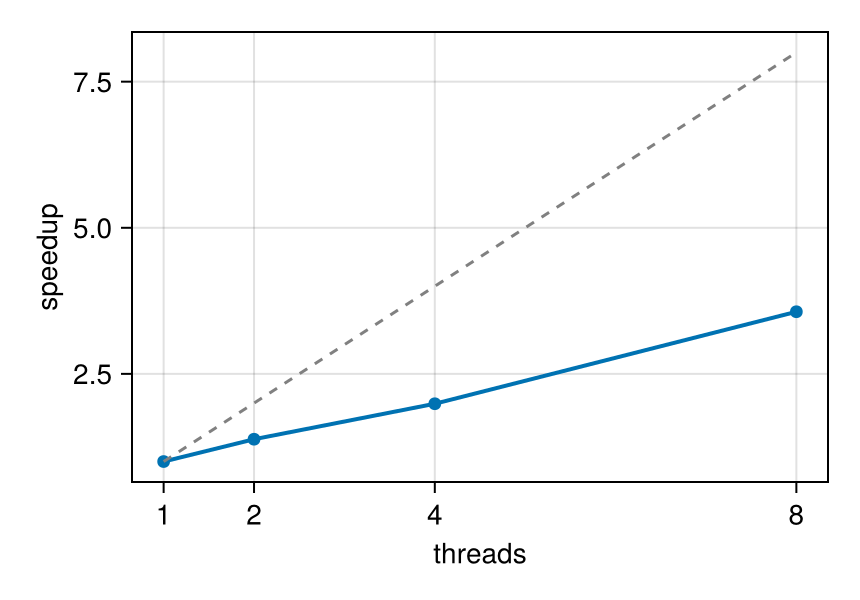

In [4]:
# Sweep only up to the threads this session actually has: max_threads is clamped to
# Threads.nthreads() internally, so asking for more silently repeats the last point.
nts = [n for n in (1, 2, 4, 8, 16, 24) if n <= Threads.nthreads()]
println("Julia threads: ", Threads.nthreads(), "  ->  testing ", nts)
# compute-heavy workload: off-axis projection with the analytic :exact deposit kernel
heavy(nt) = projection(gas, :sd; inclination=60, azimuth=30, pxsize=[0.05, :kpc],
                       binning=:exact, max_threads=nt, verbose=false, show_progress=false)
heavy(1)                                             # compile once
times = [minimum(@elapsed(heavy(nt)) for _ in 1:2) for nt in nts]
for (nt, t) in zip(nts, times)
    println(rpad("max_threads=$nt", 15), round(t, digits=2), " s   speedup ×",
            round(times[1] / t, digits=2))
end
fig = Figure(size=(430, 300))
ax = Axis(fig[1, 1], xlabel="threads", ylabel="speedup", xticks=nts)
lines!(ax, nts, times[1] ./ times, linewidth=2); scatter!(ax, nts, times[1] ./ times)
lines!(ax, nts, Float64.(nts), linestyle=:dash, color=:gray)   # ideal
fig

The dashed line is ideal scaling; the gap to it is the serial fraction.

**Which path you are on decides what to do.** For an axis-aligned projection, ask for the
quantities you need in one call rather than looping: one call for four variables threads four
ways, four calls of one variable each thread one way and walk the data four times.

```julia
proj = projection(gas, [:sd, :T, :vx, :vy])    # threads over the four variables
```

For off-axis or `:exact` work a single quantity already uses the threads: the sweep above
reaches 3.56x at 8 threads on one variable, which the axis-aligned path cannot do at any
thread count. Nothing extra is needed there. Throttle individual calls (`max_threads=4`) when you run several analyses at once or
share the machine.
The examples throughout these docs use at most 8 threads, treat that as a sensible laptop
ceiling, not a recommendation to buy more cores.

## 6. Where to go next

- [First Steps](00_multi_FirstSteps.md), the full introductory tutorial.
- [Coming from Other Analysis Tools](switching_to_mera.md), concept mapping + one complete workflow.
- [Julia Cheat Sheet](quickreference/Julia_Quick_Reference.md), syntax in one place.
- [Multi-Threading guide](multi-threading/multi-threading_intro.md), the full threading reference.
